In [1]:
!pip install torchcam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [2]:
!pip install kaggle pandas torchvision

In [3]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.utils.data as data
from torchvision.models import vgg11_bn
from torchcam.methods import GradCAM
from torch.utils.data import random_split
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import os
import random
from tqdm import tqdm
from torch.utils.data import DataLoader, WeightedRandomSampler


In [4]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

**Setting the device**

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # set device
print(device)

cuda


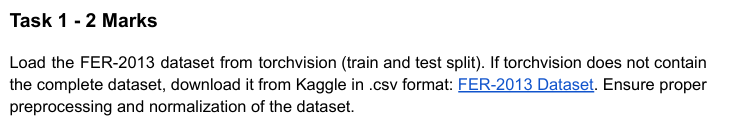

In [7]:
df = pd.read_csv("/content/fer2013.csv")

In [8]:
print(df.columns)


Index(['emotion', 'pixels', 'Usage'], dtype='object')


In [9]:
# Extracting labels
y_values = torch.tensor(df["emotion"].values)

# Getting unique labels
unique_labels = torch.unique(y_values)

print(unique_labels)

tensor([0, 1, 2, 3, 4, 5, 6])


In [10]:
# Getting unique labels
unique_labels = sorted(df["emotion"].unique())  # Ensure labels are sorted

**Assigning corresponding emotions based on each the image visualization for each label value**

In [11]:
# Dictionary to store 5 images per unique label
images_per_label = {label: [] for label in unique_labels}

# Iterating through dataset and collecting 5 images per label
for _, row in tqdm(df.iterrows(), total=df.shape[0]):
    pixel_values = row['pixels'].split()  # Convert pixel string to list
    num_pixels = len(pixel_values)  # Check number of pixels

    if num_pixels != 2304:  # If incorrect number of pixels, we print error
        print(f"Skipping row with {num_pixels} pixels instead of 2304.")
        continue  # Skipping that row

    pixels = np.array(pixel_values, dtype=np.uint8).reshape(48, 48)  # Convert string to 48x48 image
    emotion_label = row['emotion']  # Getting numeric label

    # Storing 5 images per label
    if len(images_per_label[emotion_label]) < 5:
        images_per_label[emotion_label].append(pixels)

    # Stopping the iteration after all labels have been taken care of
    if all(len(images) == 5 for images in images_per_label.values()):
        break


  1%|▏         | 533/35887 [00:00<00:57, 613.82it/s]


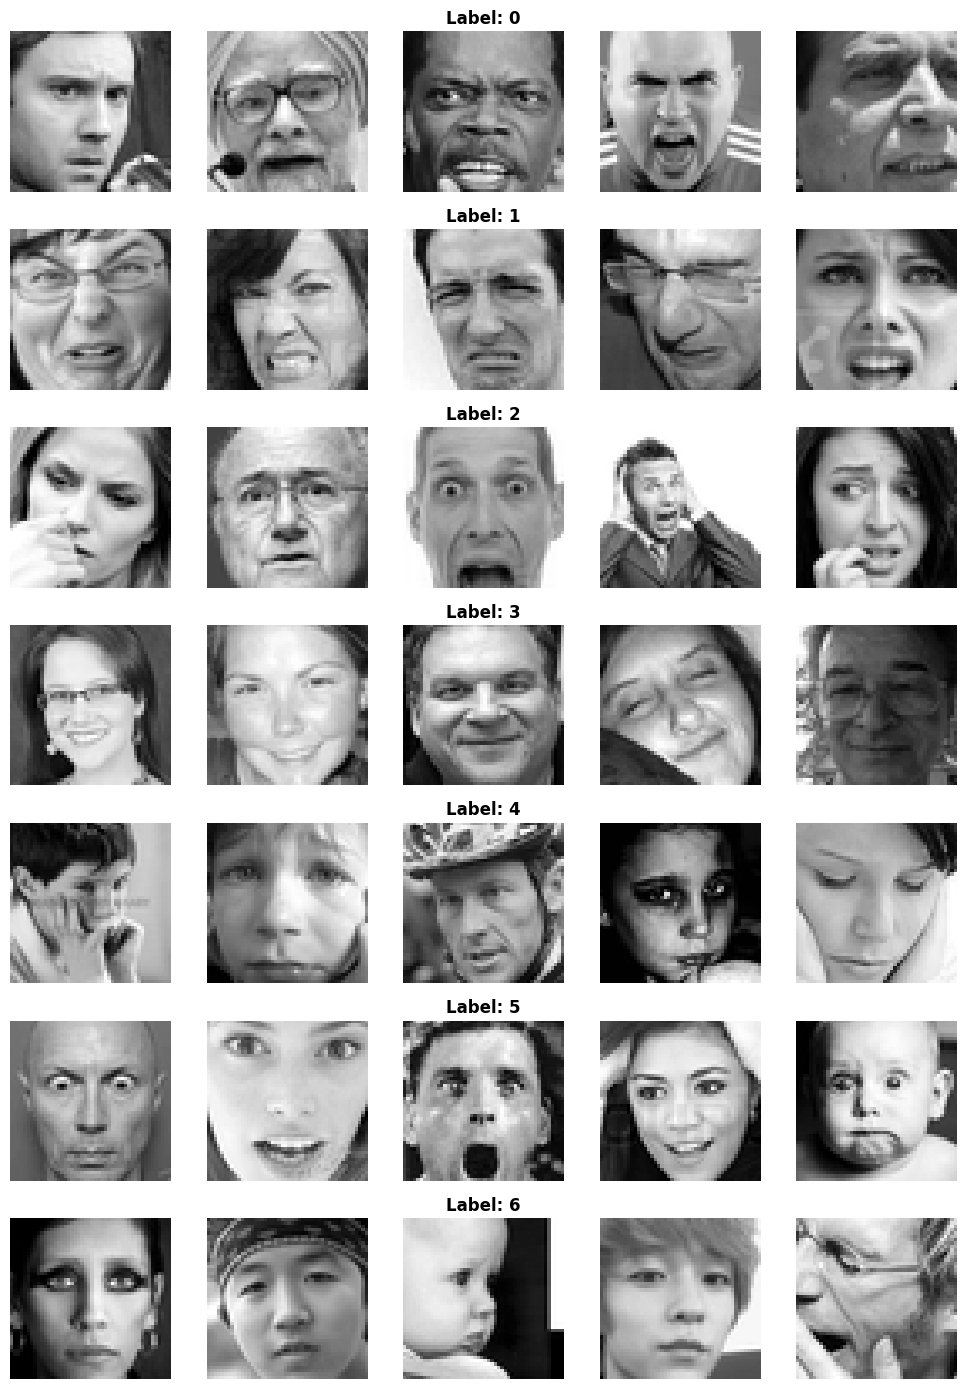

In [12]:
fig, axes = plt.subplots(nrows=len(unique_labels), ncols=5, figsize=(10, 14))

for row_idx, label in enumerate(unique_labels):
    for col_idx, image in enumerate(images_per_label[label]):
        ax = axes[row_idx, col_idx]
        ax.imshow(image, cmap='gray')  # Show image in grayscale
        ax.axis("off")
        if col_idx == 2:  # Center column for label text
            ax.set_title(f"Label: {label}", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [13]:
# Defining emotion labels based on observed images for each label
emotions = {0: "Angry", 1: "Disgust", 2: "Fear", 3: "Happy", 4: "Sad", 5: "Surprise", 6: "Neutral"}

In [14]:
# Directory creation for train & test images
os.makedirs("./data/train", exist_ok=True)
os.makedirs("./data/test", exist_ok=True)

In [15]:
# Emotion subfolders for both train and test
for emotion in emotions.values():
    os.makedirs(f"./data/train/{emotion}", exist_ok=True)
    os.makedirs(f"./data/test/{emotion}", exist_ok=True)

In [16]:
for index, row in tqdm(df.iterrows(), total=df.shape[0]):
    pixel_values = row['pixels'].split()  # Conversion of pixel string to list
    num_pixels = len(pixel_values)  # Checking on number of pixels

    if num_pixels != 2304:  # If the number of pixels is incorrect,we print an error
        print(f"Row {index} has {num_pixels} pixels instead of 2304.")
        continue  # Skipping that row having wrong num of pixels

    pixels = np.array(pixel_values, dtype=np.uint8).reshape(48, 48)  # Converting string to image array
    emotion = emotions[row['emotion']]  # Getting the label of emotion

    # Train Test folder
    folder = "train" if row['Usage'] == "Training" else "test"
    path = f"./data/{folder}/{emotion}"


    img = Image.fromarray(pixels)
    img.save(f"{path}/{index}.png")

print(" Images successfully saved!")

100%|██████████| 35887/35887 [00:41<00:00, 869.44it/s] 

 Images successfully saved!


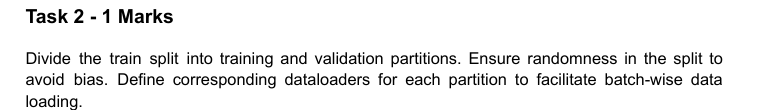

In [17]:
# Defining paths for both train & test data
train_path = "./data/train"
test_path = "./data/test"

# Loading dataset using ImageFolder
train_dataset = ImageFolder(root=train_path)
test_dataset = ImageFolder(root=test_path)

# Splitting train_dataset into training and validation partitions
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

# Random split done to avoid bias
train_set, val_set = random_split(train_dataset, [train_size, val_size])

In [18]:
print(f"Total Training Images: {len(train_dataset)}")
print(f"Total Testing Images: {len(test_dataset)}")

Total Training Images: 28709
Total Testing Images: 7178


In [19]:
import os


train_path = "./data/train"
test_path = "./data/test"

# Counting the number of images in each emotion folder for training and testing
def count_images_in_folder(path):
    counts = {}
    for emotion in os.listdir(path):
        emotion_path = os.path.join(path, emotion)
        if os.path.isdir(emotion_path):
            counts[emotion] = len(os.listdir(emotion_path))
    return counts


train_counts = count_images_in_folder(train_path)
test_counts = count_images_in_folder(test_path)


print("\n Training Data Counts:")
for emotion, count in train_counts.items():
    print(f"{emotion}: {count} images")

print("\n Testing Data Counts:")
for emotion, count in test_counts.items():
    print(f"{emotion}: {count} images")


 Training Data Counts:
Fear: 4097 images
Surprise: 3171 images
Neutral: 4965 images
Angry: 3995 images
Disgust: 436 images
Sad: 4830 images
Happy: 7215 images

 Testing Data Counts:
Fear: 1024 images
Surprise: 831 images
Neutral: 1233 images
Angry: 958 images
Disgust: 111 images
Sad: 1247 images
Happy: 1774 images


**Plotting number of images for each of the emotions in the training_set**

<ipython-input-20-bc86e79b2a45>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_labels, y=train_counts_values, palette="viridis")


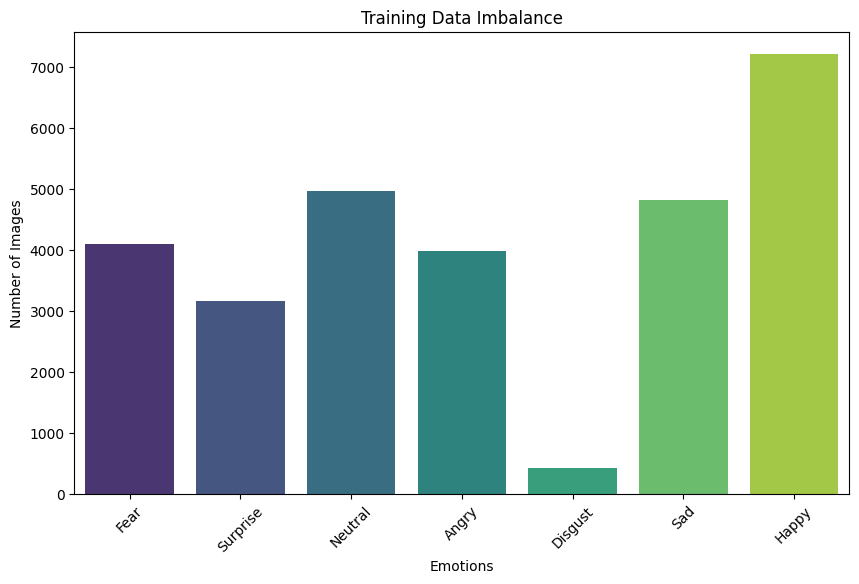

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns


train_labels = list(train_counts.keys())
train_counts_values = list(train_counts.values())


plt.figure(figsize=(10, 6))
sns.barplot(x=train_labels, y=train_counts_values, palette="viridis")

plt.title("Training Data Imbalance")
plt.xlabel("Emotions")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

As we can see the class is highly disbalanced.There are **7215** images labelled as **'Happy'** but only **436** images labelled as **'Disgust'**.So number of images labelled as 'Happy' is **16** times more than that labelled as 'Disgust'. So I have handled this class imbalance using strategy of customizing class weights (I have used weighted Cross Entropy as Loss Function so the model is **penalized more for incorrect predictions on the minority classes** like 'Disgust' rather than on majority classes like 'Happy').This weighted loss function based on class basically helps the model focus on the prediction of minortity samples and **prevents the model from completely ignoring the minority samples.**

In [21]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((48,48)),
    transforms.Grayscale(num_output_channels=3),  # adjusting channel dim from 1 to 3 for better comaptibility of my customized CNN Model
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0,
                            translate=(0.2, 0.2),
                            shear=15,
                            scale=(0.85, 1.15)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(dtype=torch.float32),# Converting image to tensor (0-1 range)
    transforms.Normalize(mean=[0.5], std=[0.5])    # Normalizing to range [-1, 1]
])

In [22]:
test_transform = transforms.Compose([
    transforms.Resize((48,48)),
    transforms.Grayscale(num_output_channels=3),  # adjusting channel dim from 1 to 3 for better comaptibility of my customized CNN Model
    transforms.ToTensor(),                         # Converting image to tensor
    transforms.Normalize(mean=[0.5], std=[0.5])    # Normalizing to range [-1, 1]
])

In [23]:
# Ensure validation uses test transformations (no augmentation)
train_set.dataset.transform = train_transform
val_set.dataset.transform = test_transform
test_dataset.transform = test_transform

print(f"Training Samples: {len(train_set)}, Validation Samples: {len(val_set)}")


Training Samples: 22967, Validation Samples: 5742


In [24]:
# Defining batch size
batch_size = 64

# Creating DataLoaders
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(" DataLoaders Created Successfully!")

 DataLoaders Created Successfully!


In [25]:
class_names = train_dataset.classes  # ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

print("Classes Found:", class_names)

Classes Found: ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


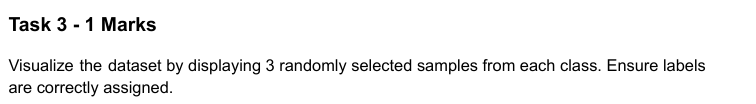

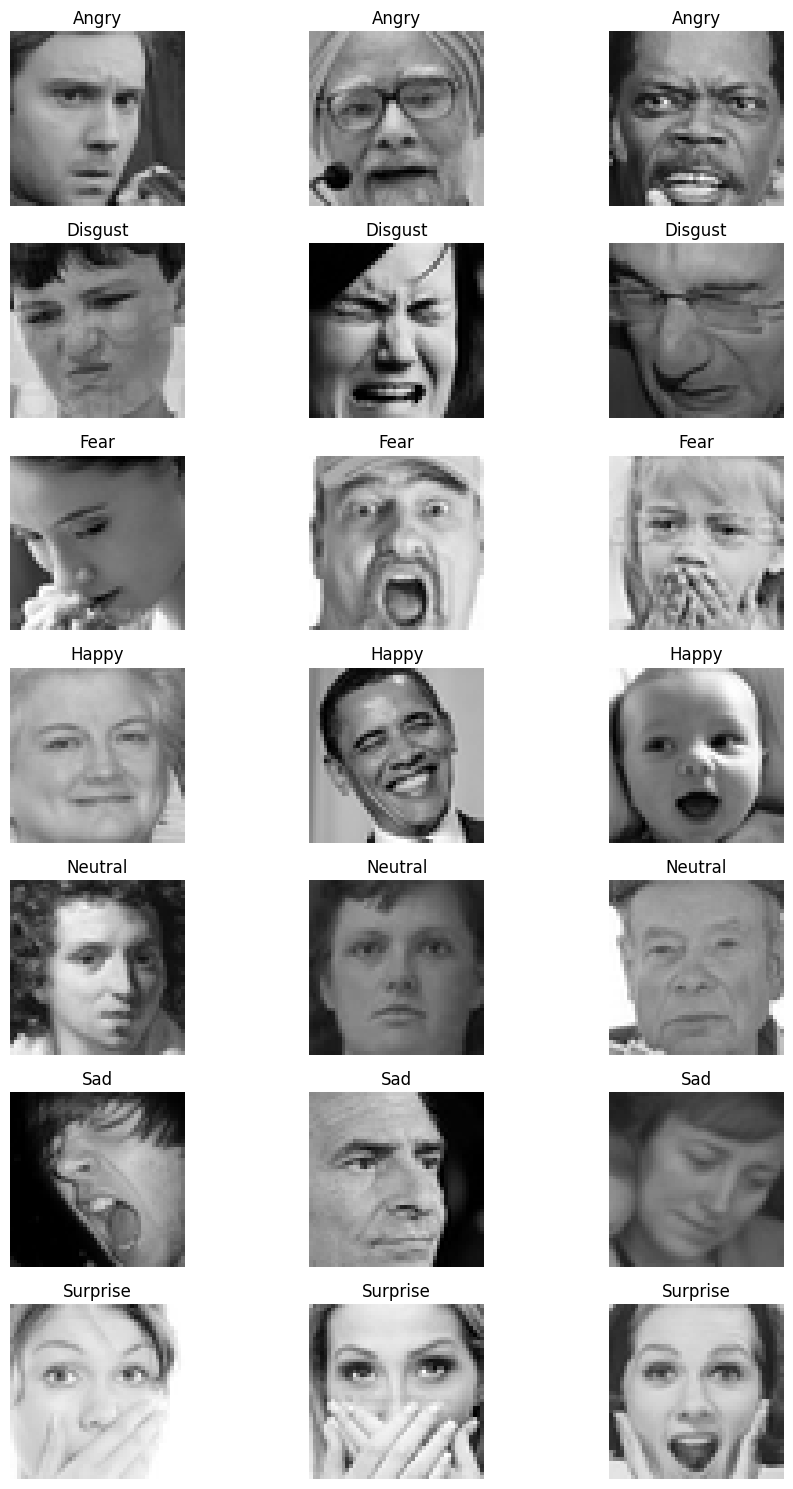

In [26]:
samples_per_class = 3

# dictionary to store image samples for each class
class_samples = {class_name: [] for class_name in class_names}

# Randomly selected 3 images per class
for img, label in train_dataset:
    class_name = class_names[label]
    if len(class_samples[class_name]) < samples_per_class:
        class_samples[class_name].append(img)
    if all(len(v) == samples_per_class for v in class_samples.values()):  # Stop if we have enough images
        break


fig, axes = plt.subplots(nrows=len(class_names), ncols=samples_per_class, figsize=(10, 15))

for row_idx, (class_name, images) in enumerate(class_samples.items()):
    for col_idx, img_tensor in enumerate(images):
        img = img_tensor.numpy().transpose(1, 2, 0)  # Convert from (C, H, W) to (H, W, C)
        img = (img * 0.5) + 0.5  # Reversing Normalization (Converting back to range [0,1])

        ax = axes[row_idx, col_idx]
        ax.imshow(img)
        ax.set_title(class_name)
        ax.axis("off")

plt.tight_layout()
plt.show()

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

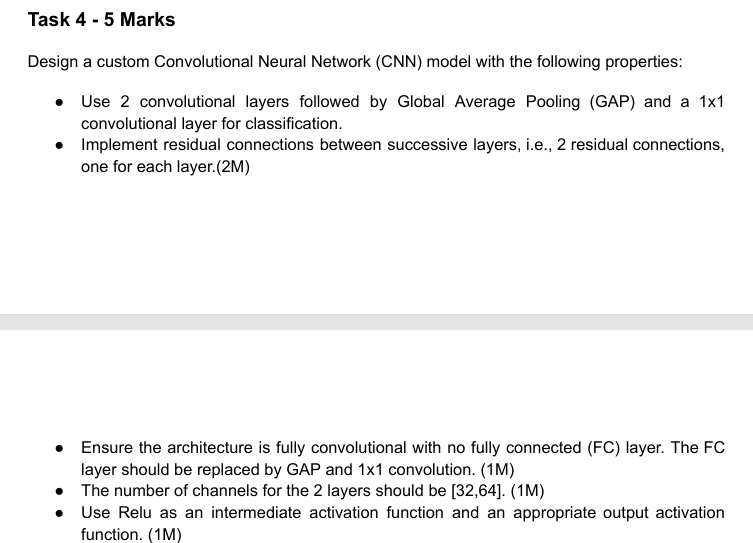

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DropBlock2D(nn.Module):
    def __init__(self, block_size=3, drop_prob=0.3):
        super(DropBlock2D, self).__init__()
        self.block_size = block_size
        self.drop_prob = drop_prob

    def forward(self, x):
        if not self.training or self.drop_prob == 0.0:
            return x
        gamma = self.drop_prob * (x.size(2) * x.size(3)) / (self.block_size ** 2) / ((x.size(2) - self.block_size + 1) * (x.size(3) - self.block_size + 1))

        mask = (torch.rand(x.shape[0], 1, x.shape[2], x.shape[3], device=x.device) < gamma).float()
        mask = F.max_pool2d(mask, kernel_size=self.block_size, stride=1, padding=self.block_size // 2)
        mask = 1 - mask

        return x * mask * (mask.numel() / mask.sum())  # Normalization to keep mean unchanged

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_p=0.3):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.activation = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.residual_bn = nn.BatchNorm2d(out_channels)

        self.dropblock = DropBlock2D(block_size=3, drop_prob=dropout_p)  # Improved Dropout Mechanism
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        residual = self.residual_conv(x)
        residual = self.residual_bn(residual)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.activation(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += residual
        out = self.activation(out)
        out = self.pool(out)
        out = self.dropblock(out)

        return out

class CustomCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(CustomCNN, self).__init__()

        # First Residual Block (32 channels)
        self.block1 = ResidualBlock(in_channels=3, out_channels=32, dropout_p=0.3)

        # Second Residual Block (64 channels)
        self.block2 = ResidualBlock(in_channels=32, out_channels=64, dropout_p=0.3)

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Final Classification Layer
        self.classifier = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Residual Block 1
        out = self.block1(x)
        # Residual Block 2
        out = self.block2(out)

        # Global Average Pooling
        out = self.gap(out)

        # Classification
        out = self.classifier(out)

        # Flattening to (batch_size, num_classes)
        out = torch.flatten(out, 1)
        # Softmax used as an output activation function
        return F.log_softmax(out, dim=1)


In [29]:
# Instantiating the model
model = CustomCNN(num_classes=7)
print(model)

CustomCNN(
  (block1): ResidualBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (residual_conv): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (residual_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropblock): DropBlock2D()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): 

In [30]:
print(model)

CustomCNN(
  (block1): ResidualBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (residual_conv): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (residual_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropblock): DropBlock2D()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): 

In [31]:
!pip install torchviz graphviz


**Computational Graph Visualization**

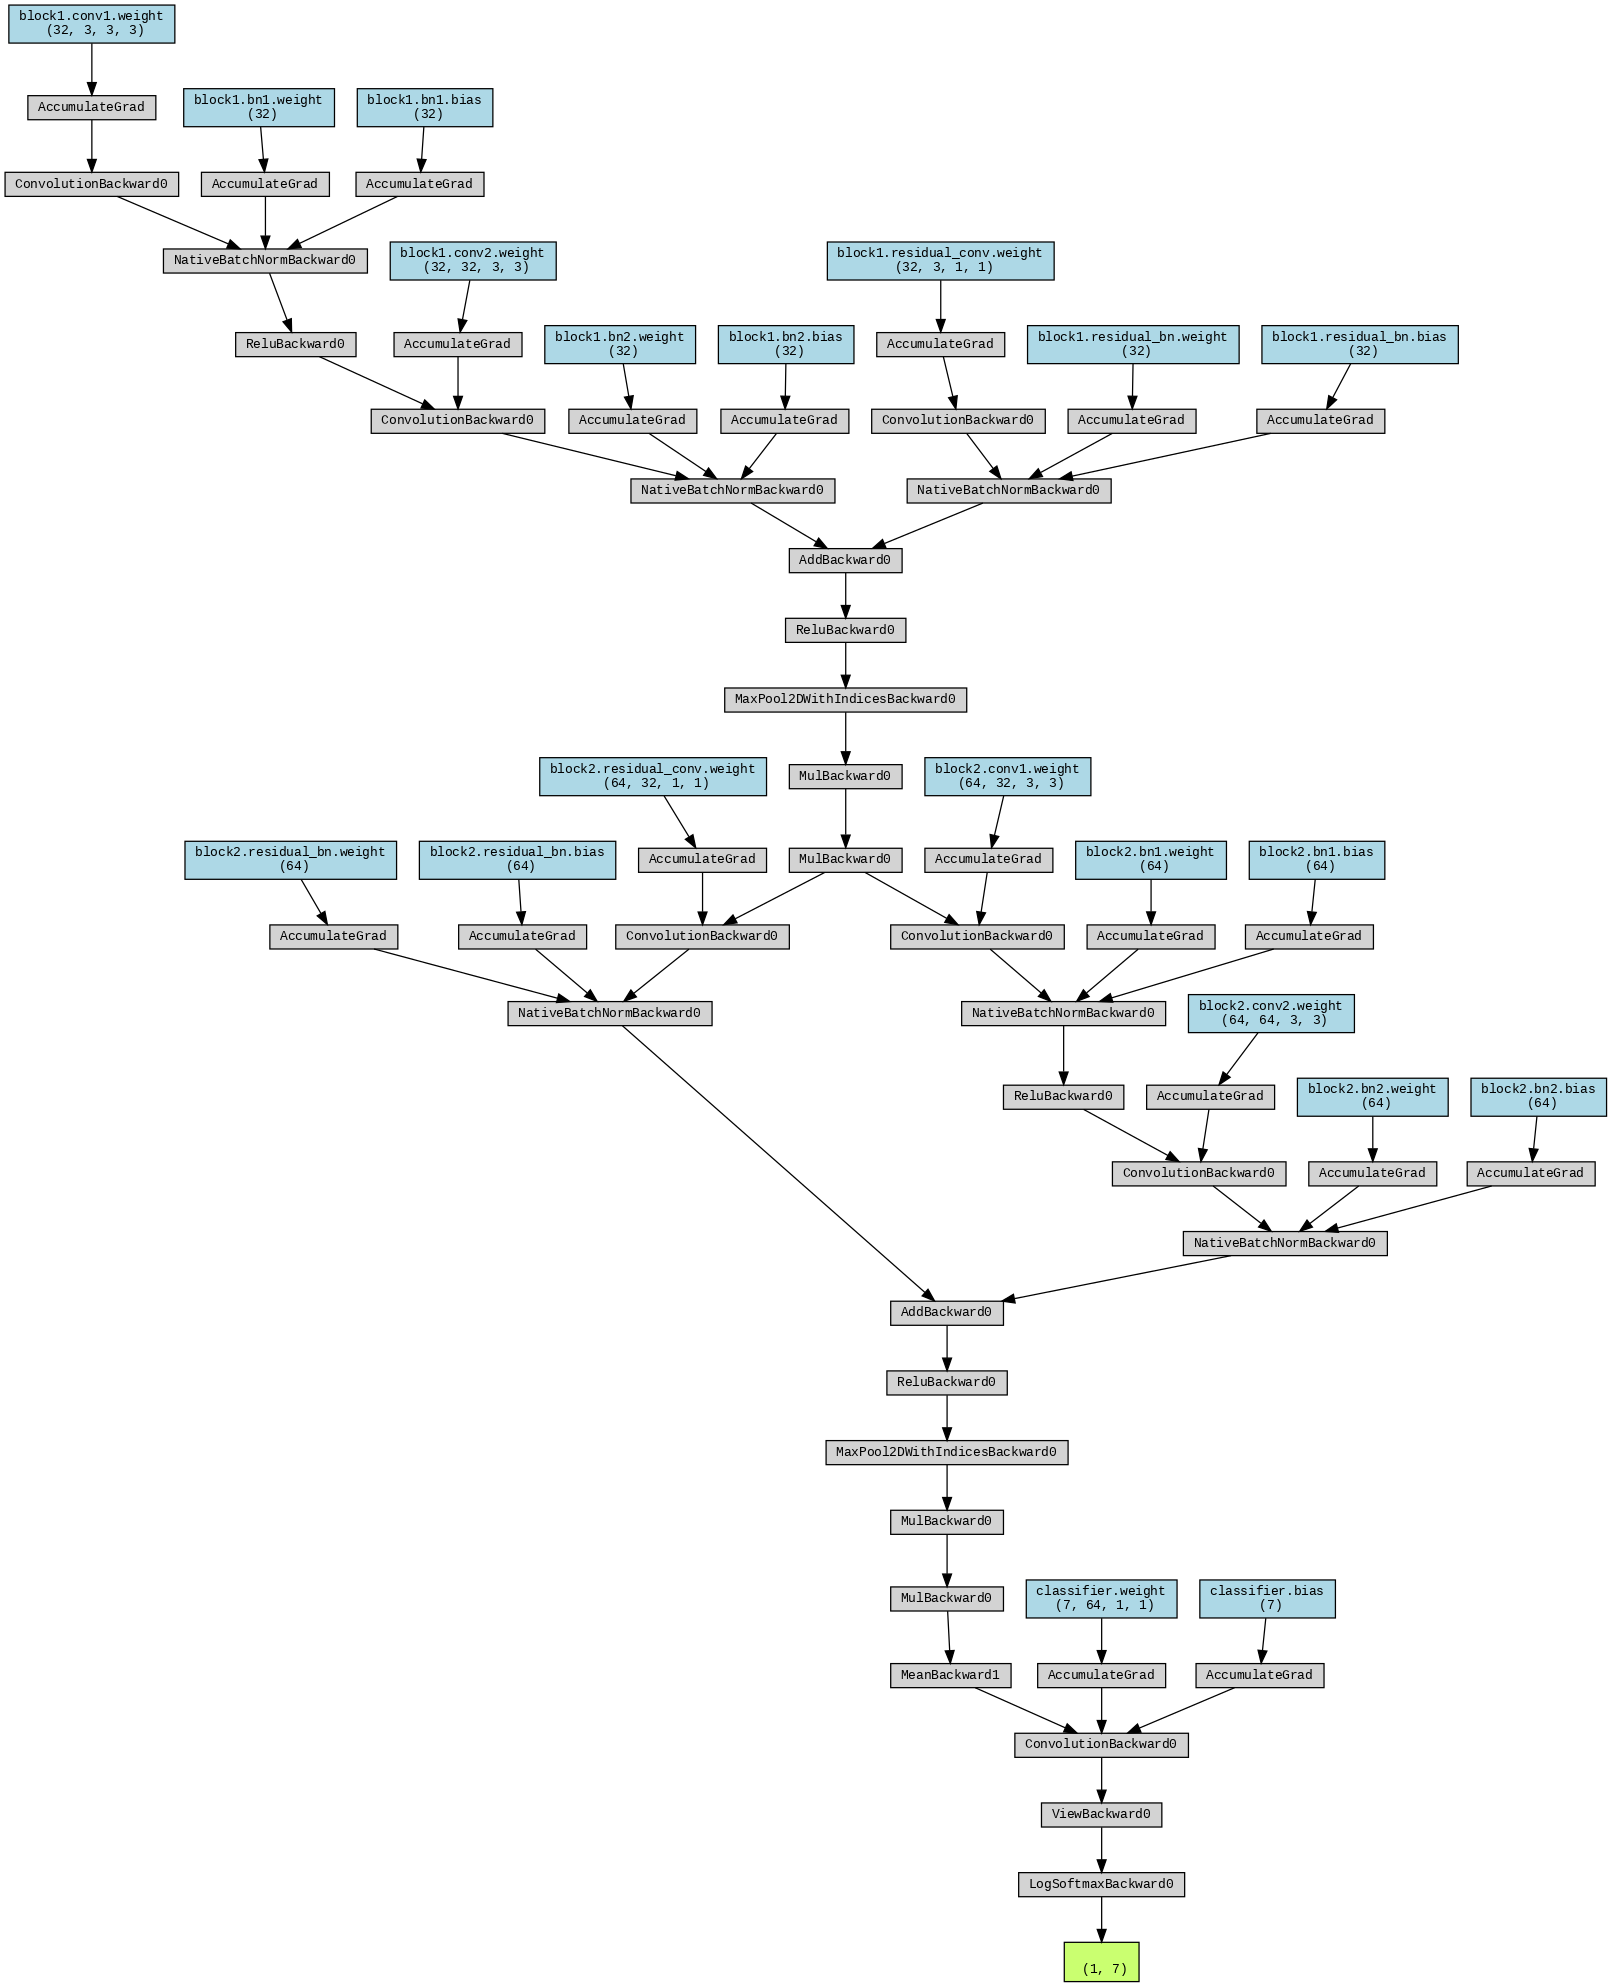

In [32]:
import torch
from torchviz import make_dot
from IPython.display import Image

# Create a dummy input (batch_size=1, channels=3, height=48, width=48)
dummy_input = torch.randn(1, 3, 48, 48)

# Forward pass through the model
output = model(dummy_input)

# Create visualization
dot = make_dot(output, params=dict(model.named_parameters()))

# Save as PNG
dot.format = 'png'
dot.render('model_architecture')

# Display the image in Colab
Image(filename='model_architecture.png')



In [33]:
# Instantiating the model
model = CustomCNN(num_classes=7)
print(model)

# Example input tensor (batch size = 8, channels = 3, image size = 48x48)
x = torch.randn(8, 3, 48, 48)

# Forward pass
output = model(x)

# Checking output shape
print("Output shape:", output.shape)  # Expected: (8, 7)


CustomCNN(
  (block1): ResidualBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (residual_conv): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (residual_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropblock): DropBlock2D()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): 

**We compute Normalized class weights to use Cross-Entropy Loss function which is weighted wrt normalized class weights so that the cost fnc is such that it penalizes the model more when it misclassifies minority class like 'Disgust' than in comparison to majority classes like 'Happy'**

In [34]:
import torch
import numpy as np

num_classes = 7
class_counts = np.zeros(num_classes)

for _, labels in train_loader:
    for label in labels:
        class_counts[label] += 1
total_samples = np.sum(class_counts)
# Computing normalized class weights
class_weights = total_samples / (num_classes * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32, requires_grad=False).to(device)

print("Class Weights:", class_weights)

Class Weights: tensor([1.0292, 9.6785, 0.9868, 0.5722, 0.8374, 0.8409, 1.2811],
       device='cuda:0')


In [35]:
class_weights = class_weights.to(device)


In [36]:
print("Class Weights:", class_weights)
print("Is tensor on correct device? ->", class_weights.device == torch.device(device))
print("Requires Grad? ->", class_weights.requires_grad)


Class Weights: tensor([1.0292, 9.6785, 0.9868, 0.5722, 0.8374, 0.8409, 1.2811],
       device='cuda:0')
Is tensor on correct device? -> False
Requires Grad? -> False


In [37]:
print("Using device:", device)


Using device: cuda


In [38]:
class_weights = class_weights.to(device)


We have to ensure class weights are on correct device for proper usage

In [39]:
print("Using device:", device)

print("Class Weights:", class_weights)
print("Is tensor on correct device? ->", class_weights.device.type == device.type)

print("Requires Grad? ->", class_weights.requires_grad)


Using device: cuda
Class Weights: tensor([1.0292, 9.6785, 0.9868, 0.5722, 0.8374, 0.8409, 1.2811],
       device='cuda:0')
Is tensor on correct device? -> True
Requires Grad? -> False


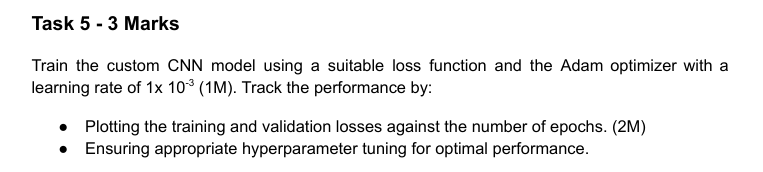

In [40]:
model = model.to(device)
# criterion = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

In [41]:
print("Using device:", device)
print("Class Weights:", class_weights)
print("Is tensor on correct device? ->", class_weights.device.type == device.type)
print("Requires Grad? ->", class_weights.requires_grad)


Using device: cuda
Class Weights: tensor([1.0292, 9.6785, 0.9868, 0.5722, 0.8374, 0.8409, 1.2811],
       device='cuda:0')
Is tensor on correct device? -> True
Requires Grad? -> False


Best model (loss) saved at epoch 1 with val loss: 1.8730
Best model (accuracy) saved at epoch 1 with val accuracy: 27.52%
Epoch 1/50, Train Loss: 1.9035, Train Acc: 22.04%, Val Loss: 1.8730, Val Acc: 27.52%
Best model (loss) saved at epoch 2 with val loss: 1.8595
Best model (accuracy) saved at epoch 2 with val accuracy: 30.74%
Epoch 2/50, Train Loss: 1.8658, Train Acc: 24.86%, Val Loss: 1.8595, Val Acc: 30.74%
Best model (loss) saved at epoch 3 with val loss: 1.8125
Epoch 3/50, Train Loss: 1.8288, Train Acc: 26.82%, Val Loss: 1.8125, Val Acc: 27.50%
Epoch 4/50, Train Loss: 1.7809, Train Acc: 29.31%, Val Loss: 1.8787, Val Acc: 29.19%
Best model (accuracy) saved at epoch 5 with val accuracy: 34.50%
Epoch 5/50, Train Loss: 1.7554, Train Acc: 30.60%, Val Loss: 1.8457, Val Acc: 34.50%
Best model (loss) saved at epoch 6 with val loss: 1.7320
Best model (accuracy) saved at epoch 6 with val accuracy: 38.33%
Epoch 6/50, Train Loss: 1.7301, Train Acc: 32.05%, Val Loss: 1.7320, Val Acc: 38.33%
Be

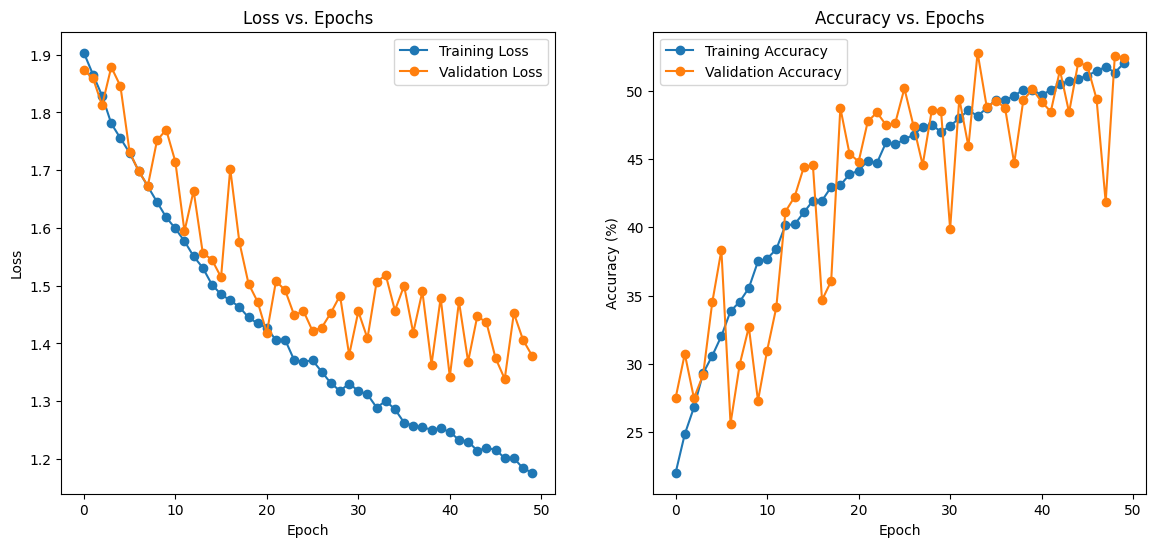

In [42]:
import matplotlib.pyplot as plt
import torch

num_epochs = 50
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_loss = float('inf')  # Initialized loss val with infinity
best_val_acc = 0  # Initialized accuracy val with 0
best_model_loss_path = "best_model_weights.pth" # best model wrt loss
best_model_acc_path = "best_model_acc.pth" # best model wrt accuracy

model = model.to(device)

for epoch in range(num_epochs):
    # Training Phase
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(100*correct_train / total_train)

    # Validation Phase
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * correct_val / total_val
    val_accuracies.append(val_acc)
    val_losses.append(val_loss)

    # Check if this is the best validation loss so far
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_loss_path)
        print(f"Best model (loss) saved at epoch {epoch+1} with val loss: {best_val_loss:.4f}")

    # Check if this is the best validation accuracy so far
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_acc_path)
        print(f"Best model (accuracy) saved at epoch {epoch+1} with val accuracy: {best_val_acc:.2f}%")

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.2f}%, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

# Plot Loss & Accuracy vs. Epochs
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot Loss
axs[0].plot(train_losses, label='Training Loss', marker='o')
axs[0].plot(val_losses, label='Validation Loss', marker='o')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].set_title("Loss vs. Epochs")
axs[0].legend()

# Plot Accuracy
axs[1].plot(train_accuracies, label='Training Accuracy', marker='o')
axs[1].plot(val_accuracies, label='Validation Accuracy', marker='o')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].set_title("Accuracy vs. Epochs")
axs[1].legend()

plt.show()


In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, precision_score, confusion_matrix

def plot_confusion_matrix(conf_mat, class_names, title="Confusion Matrix"):
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()


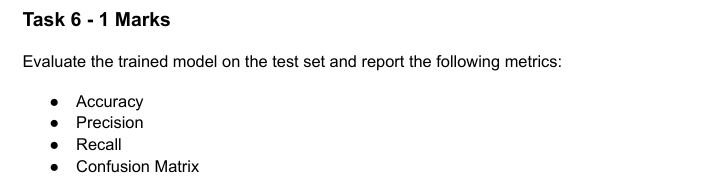

In [44]:
from sklearn.metrics import f1_score, precision_score, confusion_matrix
import torch

def evaluate_model(model, criterion, test_loader, device):
    model.eval()  # Set model to evaluation mode
    test_loss = 0.0
    correct_test = 0
    total_test = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            # Getting the predictions
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()


            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    # Calculation of overall loss and accuracy
    test_loss /= len(test_loader)
    test_accuracy = 100 * correct_test / total_test

    # Calculating other imp metrics
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    conf_mat = confusion_matrix(all_labels, all_preds)

    plot_confusion_matrix(conf_mat, class_names)

    return test_loss, test_accuracy, f1, precision, recall, conf_mat



<ipython-input-45-d26872e6633d>:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_loss.load_state_dict(torch.load(best_model_loss_path))



Evaluating Model with Best Validation Loss:


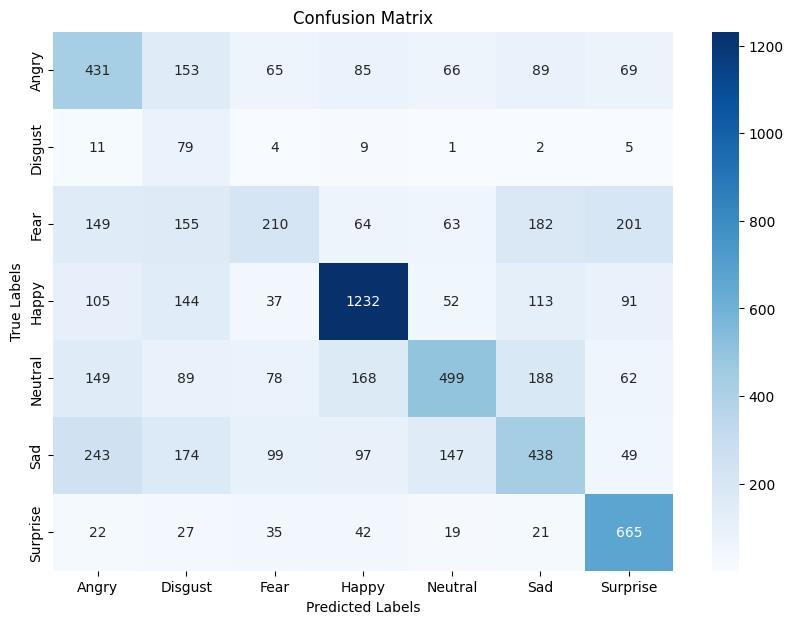

Test Loss: 1.3480
Test Accuracy: 49.51%
F1 Score: 0.4995
Precision: 0.5317
Recall: 0.4951
Confusion Matrix:
 [[ 431  153   65   85   66   89   69]
 [  11   79    4    9    1    2    5]
 [ 149  155  210   64   63  182  201]
 [ 105  144   37 1232   52  113   91]
 [ 149   89   78  168  499  188   62]
 [ 243  174   99   97  147  438   49]
 [  22   27   35   42   19   21  665]]


In [45]:
best_model_loss_path = "best_model_weights.pth"

model_loss = CustomCNN(num_classes=7)
model_loss = model_loss.to(device)



try:
    model_loss.load_state_dict(torch.load(best_model_loss_path))
except Exception as e:
    print(f"Error loading model weights: {e}")


criterion = nn.CrossEntropyLoss(weight=class_weights)

# Evaluating the model which has the best validation loss
print("\nEvaluating Model with Best Validation Loss:")
test_loss, test_accuracy, f1, precision,recall, conf_mat = evaluate_model(model_loss, criterion, test_loader, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("Confusion Matrix:\n", conf_mat)

<ipython-input-51-f09c448ffbbd>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_acc.load_state_dict(torch.load(best_model_acc_path))



Evaluating Model with Best Validation Accuracy:


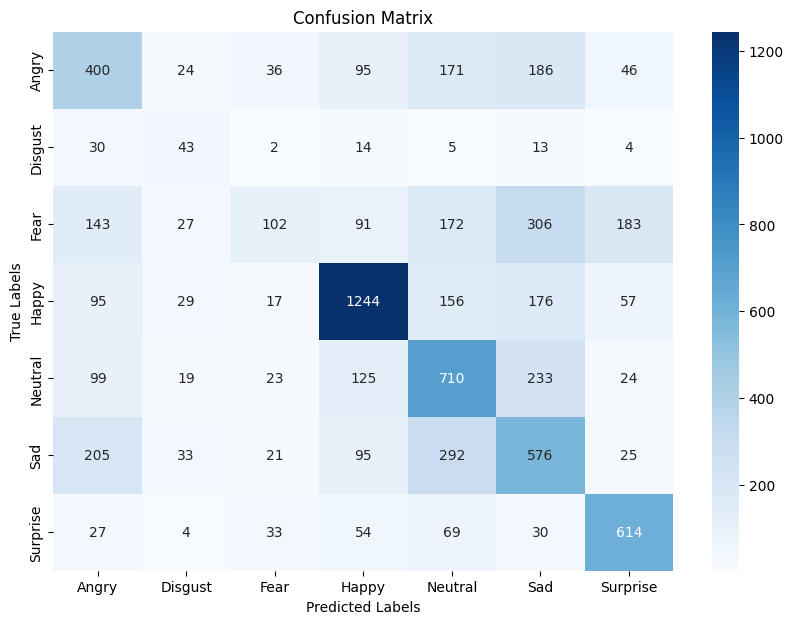

Test Loss: 1.2936
Test Accuracy: 51.39%
F1 Score: 0.4972
Precision: 0.5162
Recall: 0.5139
Confusion Matrix:
 [[ 400   24   36   95  171  186   46]
 [  30   43    2   14    5   13    4]
 [ 143   27  102   91  172  306  183]
 [  95   29   17 1244  156  176   57]
 [  99   19   23  125  710  233   24]
 [ 205   33   21   95  292  576   25]
 [  27    4   33   54   69   30  614]]


In [51]:
best_model_acc_path = "best_model_acc.pth"
model_acc = CustomCNN(num_classes=7)
model_acc = model_acc.to(device)

try:
    model_acc.load_state_dict(torch.load(best_model_acc_path))
except Exception as e:
    print(f"Error loading model weights: {e}")


criterion = nn.CrossEntropyLoss(weight=class_weights)
# Evaluating the model with the best validation accuracy
print("\nEvaluating Model with Best Validation Accuracy:")
test_loss, test_accuracy, f1, precision, recall, conf_mat = evaluate_model(model_acc, criterion, test_loader, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("Confusion Matrix:\n", conf_mat)

In [52]:
print(model_loss)

CustomCNN(
  (block1): ResidualBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (residual_conv): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (residual_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropblock): DropBlock2D()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): 

In [53]:
best_model_loss_path = "best_model_weights.pth"
model_loss.load_state_dict(torch.load(best_model_loss_path))

<ipython-input-53-ce799572d0a5>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_loss.load_state_dict(torch.load(best_model_loss_path))


<All keys matched successfully>

In [54]:
best_model_acc_path = "best_model_acc.pth"
model_acc.load_state_dict(torch.load(best_model_acc_path))

<ipython-input-54-3b04209f9ae1>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_acc.load_state_dict(torch.load(best_model_acc_path))


<All keys matched successfully>

In [55]:
print(model_acc)

CustomCNN(
  (block1): ResidualBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (residual_conv): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (residual_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dropblock): DropBlock2D()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU(inplace=True)
    (conv2): 

For our task we go for model with better accuracy on the test set

In [63]:
# we try to divie the test loaders into subsets based on emotion labels
from torch.utils.data import DataLoader, Subset

emotion_loaders = {}

for label in range(7):  # 7 classes (Angry, Neutral, Disgust, Happy, Fear, Sad, Surprise)
    indices = [i for i, (_, lbl) in enumerate(test_dataset) if lbl == label]
    subset = Subset(test_dataset, indices)
    loader = DataLoader(subset, batch_size=32, shuffle=True)
    emotion_loaders[label] = loader


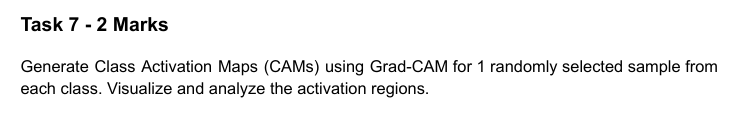

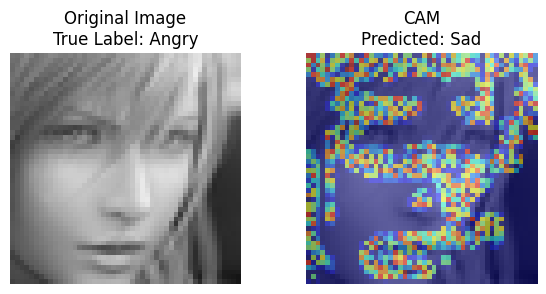

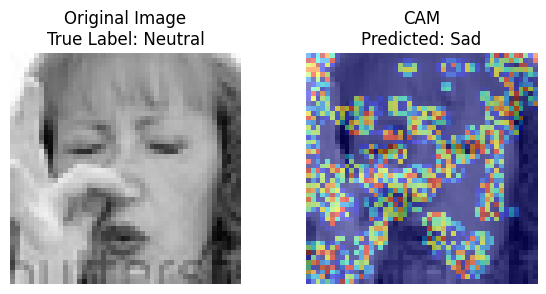

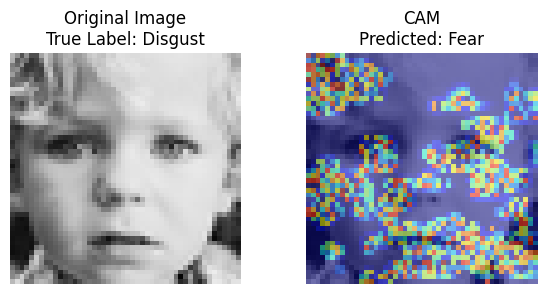

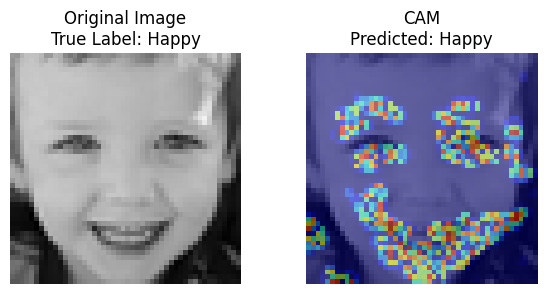

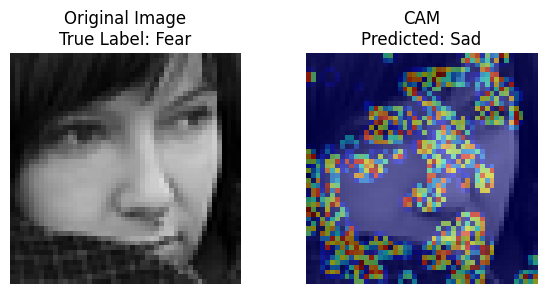

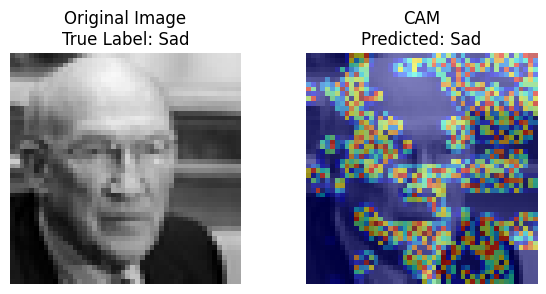

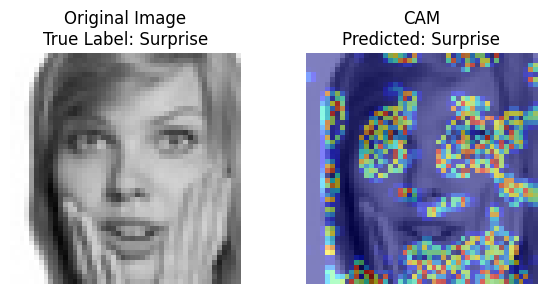

In [69]:
import torch
import random
import matplotlib.pyplot as plt
from torchvision import transforms
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
from PIL import Image
import numpy as np

# Defining mean and std for de-normalization
mean = [0.5]
std = [0.5]

# Function to denormalize the images
def denormalize(tensor, mean, std):
    mean = torch.tensor(mean).view(1, 1, 1)
    std = torch.tensor(std).view(1, 1, 1)
    return tensor * std + mean

# Emotion label mappings
emotion_classes = {
    0: "Angry",
    1: "Neutral",
    2: "Disgust",
    3: "Happy",
    4: "Fear",
    5: "Sad",
    6: "Surprise"
}

# Function to generate CAM for one random image per class
def visualize_cam_per_emotion(model, cam_extractor, emotion_loaders, device):
    model.to(device)
    model.eval()  # Setting model to evaluation mode

    for label, loader in emotion_loaders.items():
        # A random batch is picked from dataloader
        data_iter = iter(loader)
        inputs, labels = next(data_iter)
        inputs, labels = inputs.to(device), labels.to(device)

        # Finding a random image from this batch
        indices = (labels == label).nonzero(as_tuple=True)[0]
        if len(indices) == 0:
            continue

        rand_idx = random.choice(indices)
        input_img = inputs[rand_idx].unsqueeze(0)

        #  Enabling gradients for CAM computation
        input_img.requires_grad = True

        # Enabling hooks for Grad-CAM
        cam_extractor._hooks_enabled = True

        # Forward pass
        output = model(input_img)

        # Getting the predicted class
        max_prob, pred = torch.max(output, 1)

        #  Computation of Grad-CAM
        activation_map = cam_extractor(pred.item(), output, retain_graph=True)

        #  De-normalizing the image
        input_img = input_img.squeeze(0)  # Remove batch dimension
        input_img = denormalize(input_img.cpu(), mean, std).clamp(0, 1)  # Clamp to valid image range

        # Converting tensor to PIL Image
        img = transforms.ToPILImage()(input_img)

        # Converting activation map to PIL Image
        mask = activation_map[0].squeeze().cpu().numpy()
        mask = (mask - np.min(mask)) / (np.max(mask) - np.min(mask))  # Normalizing to [0,1]
        mask = Image.fromarray(np.uint8(mask * 255), mode='L')  # Converting to grayscale image

        # Overlaying the CAM on the image
        result = overlay_mask(img.convert("RGB"), mask, alpha=0.5)


        plt.figure(figsize=(7, 3))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Original Image\nTrue Label: {emotion_classes[label]}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(result)
        plt.title(f"CAM\nPredicted: {emotion_classes[pred.item()]}")
        plt.axis('off')

        plt.show()


target_layer = model_acc.block2.conv2  # Accessing last convolutional layer

#  Initializing Grad-CAM
cam_extractor = GradCAM(model_acc, target_layer=target_layer)

#  Visualization for one random image per emotion class
visualize_cam_per_emotion(model_acc, cam_extractor, emotion_loaders, device)



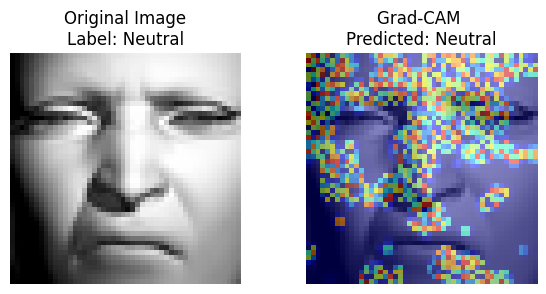

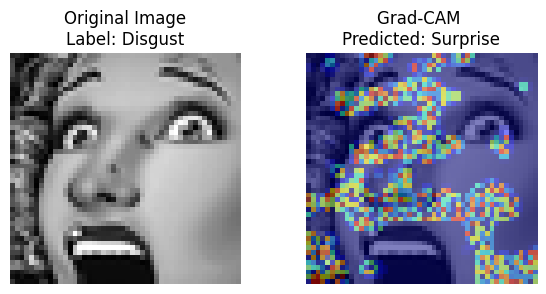

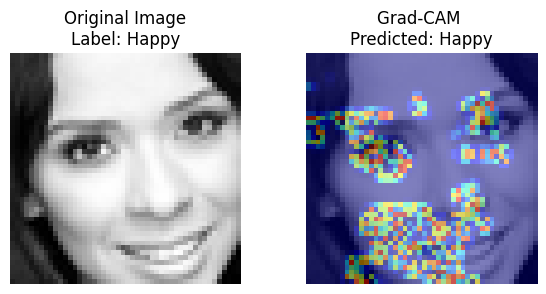

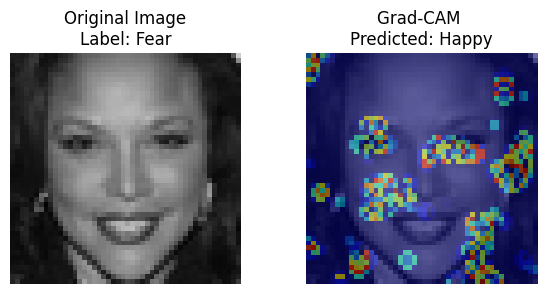

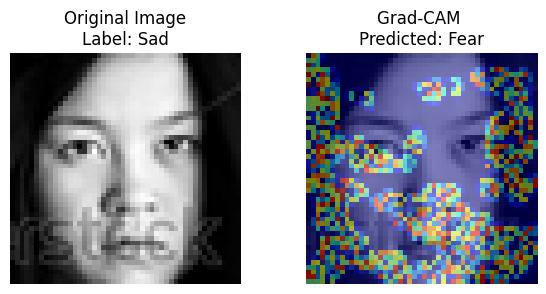

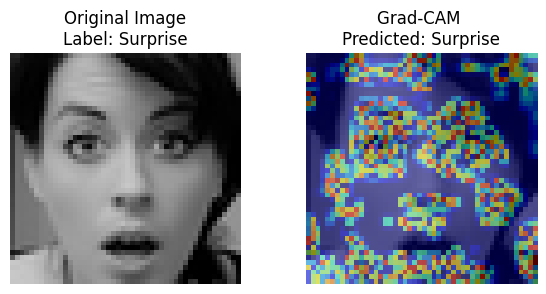

In [82]:
import torch
import random
import matplotlib.pyplot as plt
from torchvision import transforms
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
from PIL import Image
import numpy as np
import torch.nn.functional as F

mean = [0.5]
std = [0.5]

# Function to denormalize images
def denormalize(tensor, mean, std):
    mean = torch.tensor(mean).view(1, 1, 1)
    std = torch.tensor(std).view(1, 1, 1)
    return tensor * std + mean

# Emotion label mappings
emotion_classes = {
    0: "Angry",
    1: "Neutral",
    2: "Disgust",
    3: "Happy",
    4: "Fear",
    5: "Sad",
    6: "Surprise"
}


def visualize_cam_confident_predictions(model, cam_extractor, emotion_loaders, device, threshold=0.45):
    model.to(device)
    model.eval()  # Setting model to evaluation mode

    for label, loader in emotion_loaders.items():
        # Picking a random batch from the DataLoader
        data_iter = iter(loader)
        inputs, labels = next(data_iter)  # Get the first batch
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)  # Compute softmax probabilities
        max_probs, preds = torch.max(probs, 1)  # Get predicted labels and their probabilities

        # Getting indices of classified images with better confidence
        confident_indices = (max_probs > threshold).nonzero(as_tuple=True)[0]
        if len(confident_indices) == 0:
            continue  # Skipping if no good predictions in this batch


        rand_idx = random.choice(confident_indices)
        input_img = inputs[rand_idx].unsqueeze(0)
        true_label = labels[rand_idx].item()
        pred_label = preds[rand_idx].item()
        confidence = max_probs[rand_idx].item()


        input_img.requires_grad = True

        # Compute Grad-CAM
        activation_map = cam_extractor(pred_label, outputs)

        # 2D Cam
        mask = activation_map[0].squeeze().cpu().numpy()
        if mask.ndim == 3:
            mask = mask[0]  # Take only the first channel

        # Normalizing CAM
        mask = (mask - np.min(mask)) / (np.max(mask) - np.min(mask))
        mask = Image.fromarray(np.uint8(mask * 255), mode='L')  # Convert to grayscale image

        # De-normalizing the image
        input_img = input_img.squeeze(0)  # Remove batch dimension
        input_img = denormalize(input_img.cpu(), mean, std).clamp(0, 1)  # Clamp to valid image range

        # Converting tensor to PIL Image
        img = transforms.ToPILImage()(input_img)

        # Overlaying the CAM on the image
        result = overlay_mask(img.convert("RGB"), mask, alpha=0.5)
        plt.figure(figsize=(7, 3))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Original Image\nLabel: {emotion_classes[true_label]}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(result)
        plt.title(f"Grad-CAM \nPredicted: {emotion_classes[pred_label]}")
        plt.axis('off')

        plt.show()


target_layer = model_acc.block2.conv2  # Accessing last convolutional layer


cam_extractor = GradCAM(model_acc, target_layer=target_layer)
best_model_acc_path = "best_model_acc.pth"
model_acc.load_state_dict(torch.load(best_model_acc_path))

# Visualization only for predictions with better confidence
visualize_cam_confident_predictions(model_acc, cam_extractor, emotion_loaders, device, threshold=0.65)


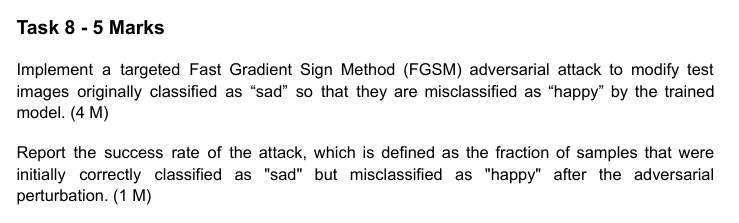

In [83]:
import torch
import torch.nn.functional as F

def targeted_fgsm_attack(model, images, labels, target_label, epsilon):
    """
    Performing a targeted FGSM attack.

    Arguments:
        model (torch.nn.Module): The trained model.
        images (torch.Tensor): Original images (batch).
        labels (torch.Tensor): Original labels (batch).
        target_label (int): The target label index to which we want to misclassify.
        epsilon (float): Perturbation magnitude.

    Returns:
        torch.Tensor: Adversarial images.
    """
    # Setting the model is in evaluation mode so that batch norm and dropout are disabled
    model.eval()

    # Creating copy of images and setting reqiures_grad to 'True' so that gradients can be tracked
    images = images.clone().detach().requires_grad_(True).to(device)

    # Generating predictions for original images
    outputs = model(images)

    # Create target labels (we want to force the model to classify as target_label)
    target_labels = torch.full_like(labels, target_label).to(device)

    # Compute the targeted loss (Minimize loss towards the target label)
    loss = F.nll_loss(outputs, target_labels)

    # Backpropagate to get gradients
    model.zero_grad()
    loss.backward()

    # Get the sign of the gradients
    grad_sign = images.grad.data.sign()

    # Create adversarial images by adjusting original images by epsilon
    adv_images = images - epsilon * grad_sign  # Note the '-' sign for targeted attack
    adv_images = torch.clamp(adv_images, 0, 1)  # Ensure the adversarial images are valid

    return adv_images


In [84]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_adversarial_samples(model, test_loader, epsilon, target_label, device, num_samples=5):
    """
    Visualizing original and adversarial samples.

    Arguments:
        model (torch.nn.Module): The trained model.
        test_loader (DataLoader): Test DataLoader.
        epsilon (float): Perturbation magnitude.
        target_label (int): The target label index (e.g., 'happy').
        device (torch.device): Device to run the model on.
        num_samples (int): Number of samples to visualize.
    """
    model.eval()
    images_displayed = 0  # Counter for displayed samples

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # Get original predictions
        original_outputs = model(images)
        _, original_preds = torch.max(original_outputs, 1)

        # Filter correctly classified "sad" images
        is_sad = (original_preds == labels) & (labels == 2)  # Assuming label 2 corresponds to "sad"

        if is_sad.sum().item() == 0:
            continue

        sad_images = images[is_sad]
        sad_labels = labels[is_sad]

        # Generate adversarial images
        adv_images = targeted_fgsm_attack(model, sad_images, sad_labels, target_label, epsilon)

        # Plot original vs adversarial images
        for i in range(min(num_samples, sad_images.size(0))):
            if images_displayed >= num_samples:
                return
            # Converting pytorch tensors to numpy arrrays for plotting
            original_image = sad_images[i].cpu().detach().permute(1, 2, 0).numpy()
            adversarial_image = adv_images[i].cpu().detach().permute(1, 2, 0).numpy()

            # Clip images to valid range [0, 1] for visualization
            original_image = np.clip(original_image, 0, 1)
            adversarial_image = np.clip(adversarial_image, 0, 1)

            original_label = original_preds[is_sad][i].item()
            adv_output = model(adv_images[i].unsqueeze(0))
            _, adv_label = torch.max(adv_output, 1)
            adv_label = adv_label.item()

            plt.figure(figsize=(8, 4))

            # Plot Original Image
            plt.subplot(1, 2, 1)
            plt.imshow(original_image)
            plt.title(f"Original: Class {original_label} ('Sad')")
            plt.axis('off')

            # Plot Adversarial Image
            plt.subplot(1, 2, 2)
            plt.imshow(adversarial_image)
            plt.title(f"Adversarial: Class {adv_label} ('Happy')")
            plt.axis('off')

            plt.show()

            images_displayed += 1


In [86]:
def evaluate_attack(model, test_loader, epsilon, target_label, device):
    """
    Evaluating the success rate of the targeted FGSM attack.

    Arguments:
        model (torch.nn.Module): The trained model.
        test_loader (DataLoader): Test DataLoader.
        epsilon (float): Perturbation magnitude.
        target_label (int): The target label index (e.g., 'happy').
        device (torch.device): Device to run the model on.

    Returns:
        float: Success rate of the attack (percentage).
    """
    correct = 0
    total = 0
    successful_attacks = 0
    original_classified_sad = 0  # Count of images originally classified as "sad"

    model.eval()

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # Check original predictions
        original_outputs = model(images)
        _, original_preds = torch.max(original_outputs, 1)

        # Focus only on correctly classified "sad" images
        is_sad = (original_preds == labels) & (labels == 2)  # Assuming "sad" has label 2
        original_classified_sad += is_sad.sum().item()

        if original_classified_sad == 0:  # No "sad" images found in this batch
            continue

        # Apply the attack only to the selected "sad" images
        sad_images = images[is_sad]
        sad_labels = labels[is_sad]

        adv_images = targeted_fgsm_attack(model, sad_images, sad_labels, target_label, epsilon)

        # Check new predictions
        adv_outputs = model(adv_images)
        _, adv_preds = torch.max(adv_outputs, 1)

        # Count successful attacks
        successful_attacks += (adv_preds == target_label).sum().item()

        total += sad_labels.size(0)

    if total == 0:
        return 0.0

    success_rate = (successful_attacks / total) * 100
    return success_rate


In [87]:
# Defining parameters for the attack
epsilon = 0.03  # Amount of perturbation to be added to the inout image for creating adversarial inputs
target_label = 3  # Since "happy" has label 3 and its the target_label

# Load the best model (trained for highest accuracy)
model_acc = CustomCNN(num_classes=7).to(device)
model_acc.load_state_dict(torch.load(best_model_acc_path))

# Running the attack
success_rate = evaluate_attack(model_acc, test_loader, epsilon, target_label, device)
print(f"Targeted FGSM Attack Success Rate: {success_rate:.2f}%")


<ipython-input-87-41fe349b6095>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_acc.load_state_dict(torch.load(best_model_acc_path))


Targeted FGSM Attack Success Rate: 82.35%


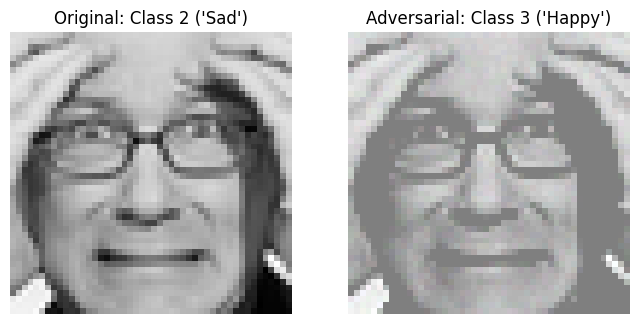

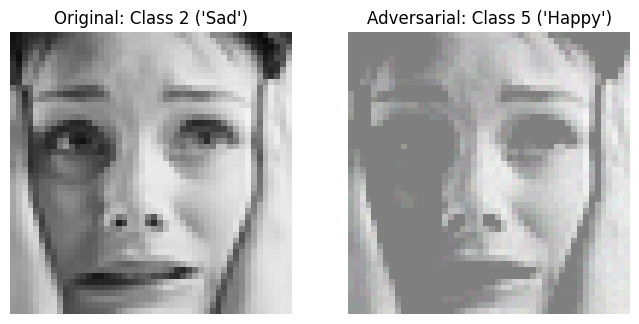

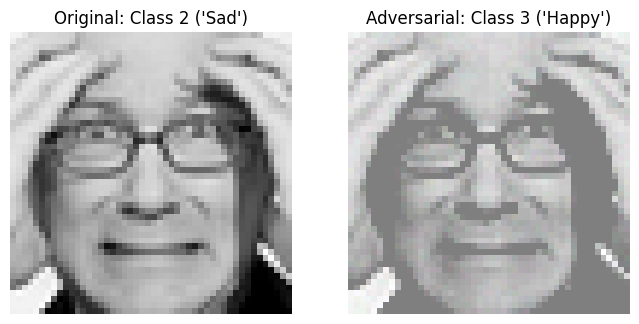

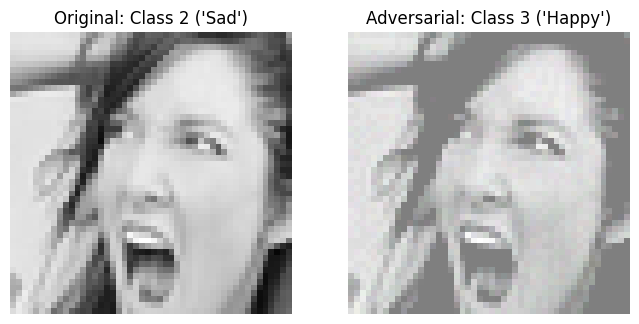

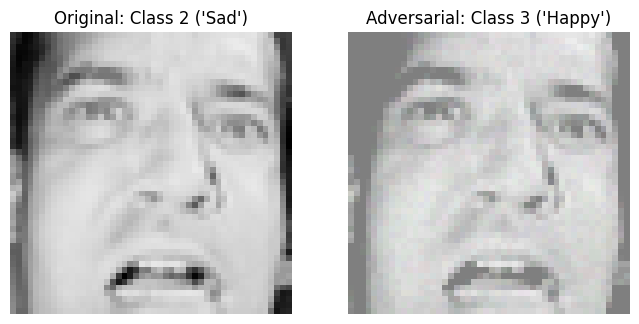

In [88]:
# Visualizing Adversarial Samples generated for images which were correctly classified as 'sad' initially
visualize_adversarial_samples(model_acc, test_loader, epsilon=0.03, target_label=3, device=device, num_samples=5)
